In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # USED ONLY TO READ THE CSV FILE

In [3]:
# Load the dataset
dataset1_path = r'C:\Users\shiva\OneDrive\Desktop\DA5401_Big_Data_Lab\FML_as1_pca_clustering.ipynb\dataset1-assignment1 - Sheet1.csv'
X1 = pd.read_csv(dataset1_path, header=None).values
X1[:5, :]  # Display the first 5 rows to verify loading

array([[2.06031874, 2.31662042],
       [3.42607063, 2.28227718],
       [3.46444152, 0.71631786],
       [2.98230101, 3.25647575],
       [0.98648793, 0.75841128]])

# Data visualisation before PCA

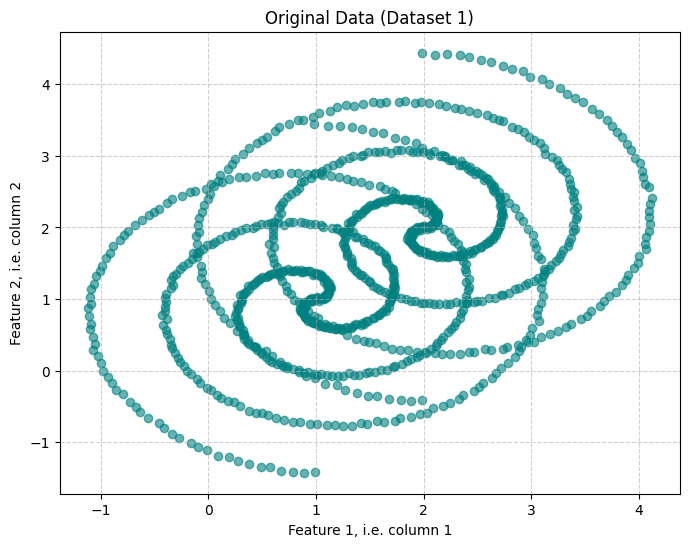

In [4]:
# Visualize the original data
plt.figure(figsize=(8,6))
plt.scatter(X1[:, 0], X1[:, 1], c='teal', alpha=0.6)
plt.title('Original Data (Dataset 1)')
plt.xlabel('Feature 1, i.e. column 1')
plt.ylabel('Feature 2, i.e. column 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Implement PCA from scratch. 
The steps are:
1. Center the data by subtracting the mean.

2. Compute the covariance matrix.

3. Find the eigenvalues and eigenvectors of the covariance matrix.

4. The eigenvectors are the principal components.

5. Calculate the variance explained by each component.


In [ ]:
#### rough debugging before implementing class #####

## ___________________IGNORE__________________  ##


# X1_centred= X1 - np.mean(X1, axis=0)
# cov_mat  = (X1_centred.T @ X1_centred)
# evals , evecs = np.linalg.eig(cov_mat)

# idx = np.argsort(evals)[::-1] # this shld just put the second eval first
# print("Pre sorting: \n", idx, evals, evecs)
# evals = evals[idx]
# evecs = evecs[:, idx]
# print("After sorting: \n", idx, evals, evecs)
# components = evecs[:, 1] # here, we chop off the second one to get dim reduction 

# total_var = np.sum(evals)
# explained_ratio = evals/total_var

# print("Total variance and explained variance: \n", total_var, explained_ratio)



In [ ]:
class PCA:
    """
    Principal Component Analysis implementation from scratch.
    """
    def __init__(self, n_components):
        self.n_components = n_components
        self.components = None
        self.mean = None
        self.explained_variance_ratio = None

    def fit_transform(self, X):
        self.mean = np.mean(X, axis=0) # mean for each column 
        X_centered = X - self.mean

        # calculate the 'covariance matrix'
        cov_matrix = (X_centered.T @ X_centered) / (X.shape[0] - 1) # (applies bezzel's correction) for current X1, this is just one
        eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

        idx = np.argsort(eigenvalues)[::-1] # sort in descending order of eigenvalues to get descending indices
        eigenvalues = eigenvalues[idx] # sort eigenvalues
        eigenvectors = eigenvectors[:, idx]

        self.components = eigenvectors[:, :self.n_components]
        total_variance = np.sum(eigenvalues)
        self.explained_variance_ratio = eigenvalues / total_variance
        return X_centered @ self.components


### Apply PCA on the Dataset

In [7]:
# Apply PCA on the dataset
# Run PCA on the dataset
n_components = X1.shape[1]
pca = PCA(n_components=n_components)
X1_pca = pca.fit_transform(X1)

# Report the variance explained
print("--- PCA Results ---")
for i, variance in enumerate(pca.explained_variance_ratio):
    print(f"Variance explained by Principal Component {i+1}: {variance:.4f} ({variance*100:.2f}%)")


--- PCA Results ---
Variance explained by Principal Component 1: 0.6539 (65.39%)
Variance explained by Principal Component 2: 0.3461 (34.61%)


In [8]:
# After fitting PCA

# examine the weight loading of the PCA
print("--- Principal Component Loadings ---")
for i, comp in enumerate(pca.components.T):
    print(f"Principal Component {i+1}:")
    for j, loading in enumerate(comp):
        print(f"  Feature {j+1}: {loading:.4f}")

--- Principal Component Loadings ---
Principal Component 1:
  Feature 1: -0.6910
  Feature 2: -0.7228
Principal Component 2:
  Feature 1: -0.7228
  Feature 2: 0.6910


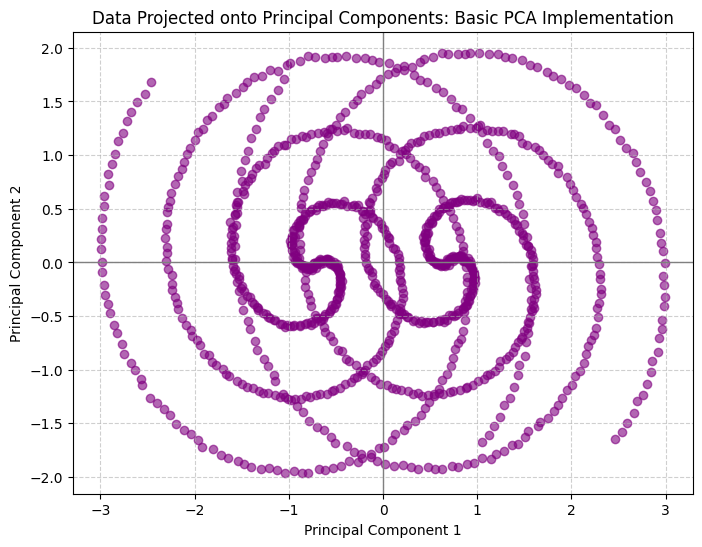

In [9]:
# Plotting the results of PCA
plt.figure(figsize=(8, 6))
plt.scatter(X1_pca[:, 0], X1_pca[:, 1], c='purple', alpha=0.6)
plt.title('Data Projected onto Principal Components: Basic PCA Implementation')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='grey', lw=1)
plt.axvline(0, color='grey', lw=1)
plt.show()


# Kernel PCA 
Implement Kernel PCA from scratch

## Define KernelPCA Class 

In [ ]:

class KernelPCA:
    def __init__(self, n_components, kernel='rbf', gamma=None, degree=3, coef0=1):
        self.n_components = n_components
        self.kernel = kernel
        self.gamma = gamma      # For RBF kernel
        self.degree = degree      # For polynomial kernel
        self.coef0 = coef0        # For polynomial kernel
        self.alphas_ = None
        self.lambdas_ = None
        self.X_fit_ = None
        self.K_fit_ = None
        self.explained_variance_ = None
        self.explained_variance_ratio_ = None
    # K[i, j] = kernel(X[i], X[j]): Calculate the kernel matrix for each kernel type

    def _get_kernel(self, X, Y=None):
        '''
        Map X onto the higher dimensional space using the specified kernel.
        '''
        if Y is None:
            Y = X
        # RBF : K(x, y) = exp(-gamma * ||x - y||^2)
        if self.kernel == 'rbf':
            # Used gamma for convenience: Conversion by γ= 1/(2σ²), i.e. sigma = sqrt(1/(2*gamma))
            if self.gamma is None:
                self.gamma = 1.0 / X.shape[1]
            # X[:, np.newaxis, :] has shape (n_samples_X, 1, n_features). Changed from (n_samples_X, n_features)
            # Y[np.newaxis, :, :] has shape (1, n_samples_Y, n_features). Changed from (n_samples_Y, n_features)
            # Use array broadcasting to find euclidean distances: [i, j, :] is X[i, :] - Y[j, :]
            dists = np.sum((X[:, np.newaxis, :] - Y[np.newaxis, :, :]) ** 2, axis=2)
            K = np.exp(-self.gamma * dists)
        
        # Linear Kernel: K(x, y) = x · y. 
        # USed for sanity check with normal PCA
        elif self.kernel == 'linear':
            K = np.dot(X, Y.T)

        # POLYNOMIAL Kernel: K(x, y) = (x · y + coef0) ^ degree
        elif self.kernel == 'polynomial':
            K = (np.dot(X, Y.T) + self.coef0) ** self.degree
        
        else:
            raise ValueError("Unsupported kernel")
        return K
    

    def fit(self, X):
        self.X_fit_ = X
        K = self._get_kernel(X)
        N = K.shape[0]
        one_n = np.ones((N, N)) / N
        # centre the kernel matrix in feature space: one_n @ K -> mean of each column, K @ one_n -> mean of each row
        # one_n @ K @ one_n -> overall mean must be added back since it was subtracted twice
        K_centered = K - one_n @ K - K @ one_n + one_n @ K @ one_n
        self.K_fit_ = K_centered

        eigvals, eigvecs = np.linalg.eigh(K_centered) # use the hermitian matrix solver for efficiency
        idx = np.argsort(eigvals)[::-1]
        eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]
        self.lambdas_ = eigvals[:self.n_components]
        self.alphas_ = eigvecs[:, :self.n_components]

        # Explained variance calculation
        total_var = np.sum(eigvals)
        self.explained_variance_ = self.lambdas_
        self.explained_variance_ratio_ = self.lambdas_ / total_var

    def transform(self, X):
        K = self._get_kernel(X, self.X_fit_)
        N = self.K_fit_.shape[0]
        one_n = np.ones((N, N)) / N
        K_centered = K - np.mean(self.K_fit_, axis=0) - np.mean(K, axis=1)[:, np.newaxis] + np.mean(self.K_fit_)
        return K_centered @ self.alphas_ / np.sqrt(self.lambdas_)

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)


--- Kernel PCA with Linear Kernel ---


Explained variance (Linear): [1632.32485707  863.82427941]
Explained variance ratio (Linear): [0.65393723 0.34606277]


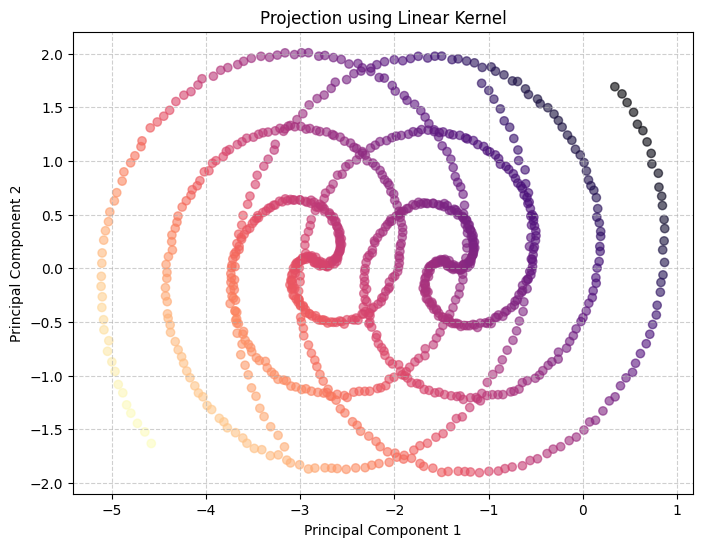

In [ ]:
# 1. Linear Kernel
print("\n--- Kernel PCA with Linear Kernel ---")
kpca_linear = KernelPCA(n_components=2, kernel='linear')
X1_kpca_linear = kpca_linear.fit_transform(X1) # can optionally pass dif X here, (Y), if want a special linear kernel
print("Explained variance (Linear):", kpca_linear.explained_variance_)
print("Explained variance ratio (Linear):", kpca_linear.explained_variance_ratio_)
plt.figure(figsize=(8, 6))
plt.scatter(X1_kpca_linear[:, 0], X1_kpca_linear[:, 1], c=X1[:, 1], cmap='magma', alpha=0.6)
plt.title('Projection using Linear Kernel')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


Explained variance (Polynomial): [818343.46568497 209834.02479017]
Explained variance ratio (Polynomial): [0.76919821 0.19723254]


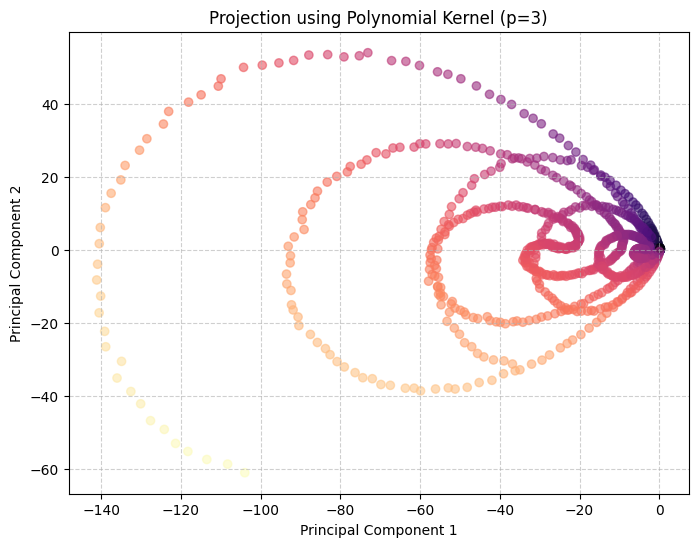

In [12]:
kpca_poly = KernelPCA(n_components=2, kernel='polynomial', degree= 3, coef0=1)
X1_kpca_poly = kpca_poly.fit_transform(X1)
print("Explained variance (Polynomial):", kpca_poly.explained_variance_)
print("Explained variance ratio (Polynomial):", kpca_poly.explained_variance_ratio_)
plt.figure(figsize=(8, 6))
plt.scatter(X1_kpca_poly[:, 0], X1_kpca_poly[:, 1], c=X1[:, 1], cmap='magma', alpha=0.6)
plt.title('Projection using Polynomial Kernel (p=3)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


--- Kernel PCA with RBF Kernels ---
Explained variance (RBF, sigma=0.05): [11.92782757 11.24332945]
Explained variance ratio (RBF, sigma=0.05): [0.01197581 0.01128856]


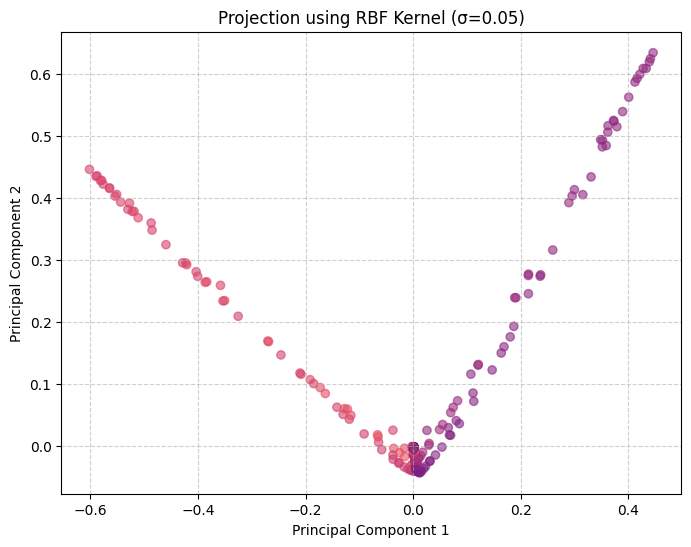

Explained variance (RBF, sigma=0.1): [23.78569625 21.69899742]
Explained variance ratio (RBF, sigma=0.1): [0.02399835 0.021893  ]


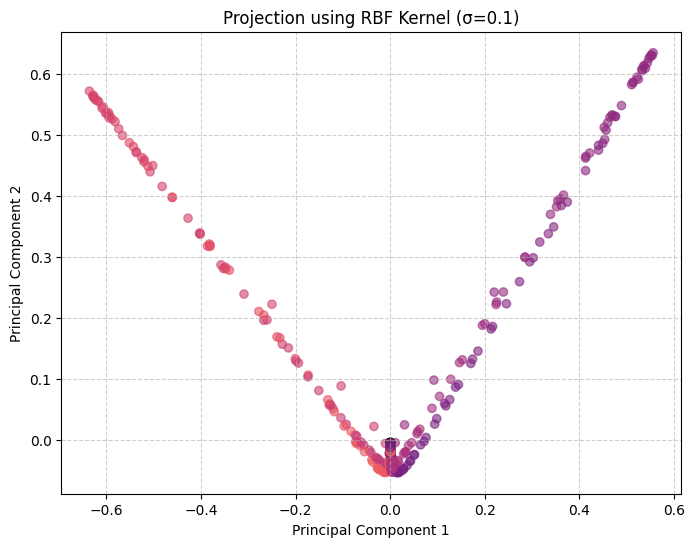

Explained variance (RBF, sigma=0.2): [46.31785796 39.03112572]
Explained variance ratio (RBF, sigma=0.2): [0.04732267 0.03987786]


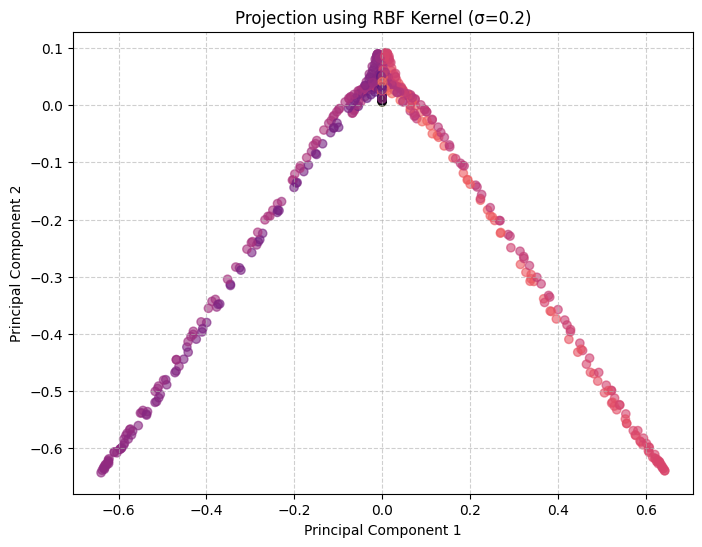

Explained variance (RBF, sigma=1): [165.4902757  114.36893801]
Explained variance ratio (RBF, sigma=1): [0.23217554 0.16045457]


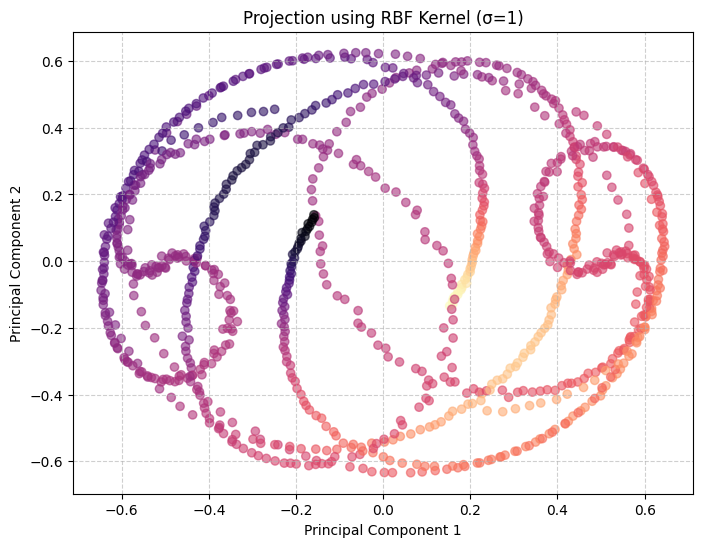

Explained variance (RBF, sigma=5): [53.67571662 29.93364142]
Explained variance ratio (RBF, sigma=5): [0.5909814  0.32957595]


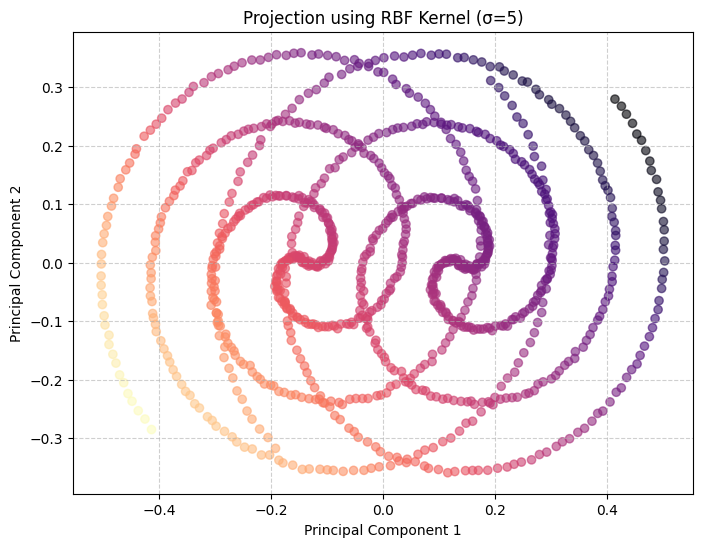

Explained variance (RBF, sigma=10): [15.51016511  8.32447769]
Explained variance ratio (RBF, sigma=10): [0.63677146 0.34176231]


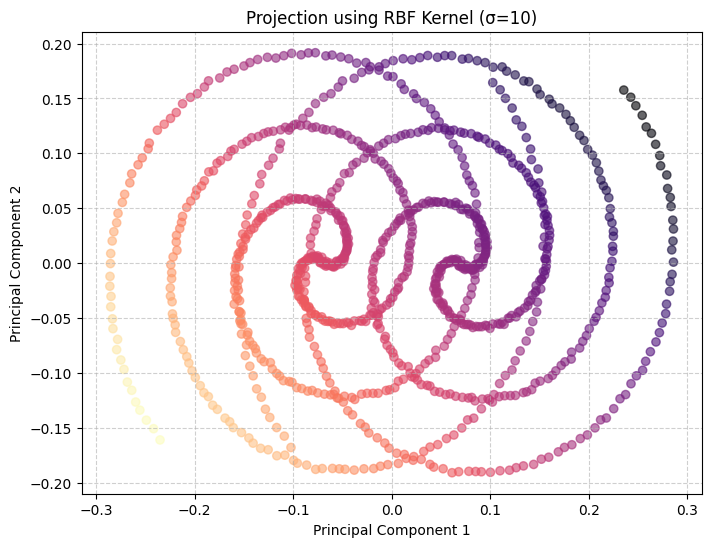

In [13]:
# 3. RBF Kernel with different sigma values
print("\n--- Kernel PCA with RBF Kernels ---")
gammas = [0.05, 0.1, 0.2,  1, 5, 10] # use s as placeholder cause of sigma! 
for s in gammas:
    kpca_rbf = KernelPCA(n_components=2, kernel='rbf', gamma=1/(2*s**2))
    X1_kpca_rbf = kpca_rbf.fit_transform(X1)
    print(f"Explained variance (RBF, sigma={s}):", kpca_rbf.explained_variance_)
    print(f"Explained variance ratio (RBF, sigma={s}):", kpca_rbf.explained_variance_ratio_)
    plt.figure(figsize=(8, 6))
    plt.scatter(X1_kpca_rbf[:, 0], X1_kpca_rbf[:, 1], c=X1[:, 1], cmap='magma', alpha=0.6)
    plt.title(f'Projection using RBF Kernel (σ={s})')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()